In [1]:
# Import all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re  # Regular expression

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train=pd.read_csv("/content/drive/MyDrive/ThinkCloudly/titanic_train.csv")
test=pd.read_csv("/content/drive/MyDrive/ThinkCloudly/titanic_test.csv")

In [4]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
'''
Data description:
Survival - Survival (0 = No; 1 = Yes). Not included in test.csv file.
Pclass - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)
Name - Name
Sex - Sex
Age - Age
Sibsp - Number of Siblings/Spouses Aboard
Parch - Number of Parents/Children Aboard
Ticket - Ticket Number
Fare - Passenger Fare
Cabin - Cabin
Embarked - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)
'''

'\nData description:\nSurvival - Survival (0 = No; 1 = Yes). Not included in test.csv file.\nPclass - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)\nName - Name\nSex - Sex\nAge - Age\nSibsp - Number of Siblings/Spouses Aboard\nParch - Number of Parents/Children Aboard\nTicket - Ticket Number\nFare - Passenger Fare\nCabin - Cabin\nEmbarked - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)\n'

In [6]:
train.shape

(891, 12)

In [7]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
train["Name"].value_counts()

,count
Name,
"Dooley, Mr. Patrick",1
"Braund, Mr. Owen Harris",1
"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",1
"Heikkinen, Miss. Laina",1
"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1
...,...
"Hewlett, Mrs. (Mary D Kingcome)",1
"Vestrom, Miss. Hulda Amanda Adolfina",1
"Andersson, Mr. Anders Johan",1


In [10]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
# ??? could the lambda function be applied to full_data.

original_train=train.copy()  # assigning train data into original_train - or copying train data

full_data=[train,test]       # assigning train and test data into full_data

#  it checks each value in the Cabin column and assigns 1 if a cabin exists, 0 if it does not or is Null
train["Has_Cabin"]=train["Cabin"].apply(lambda x: 0 if type(x)==float else 1)   # Has_Cabin of train is assigned with Cabin of train data
test["Has_Cabin"]=test["Cabin"].apply(lambda x: 0 if type(x)==float else 1)     # Has_Cabin of test is assigned with Cabin of test data

In [12]:
# ??? why Family_size+Parch+1

#create new feature Family-size as a combination of (Sibsp)SiblingSpouse and (Parch) Parentchildren
for dataset in full_data:
  dataset["Family_Size"]=dataset["SibSp"]+dataset["Parch"]+1
# create new feature if person alone from Family size
for dataset in full_data:
  dataset["Is_Alone"]=0
  dataset.loc[dataset["Family_Size"]==1,"Is_Alone"]=1


In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  Has_Cabin    891 non-null    int64  
 13  Family_Size  891 non-null    int64  
 14  Is_Alone     891 non-null    int64  
dtypes: float64(2), int64(8), object(5)
memory usage: 104.5+ KB


In [14]:
# why Embarked nulls replaced by "S"

# Remove all nulls in the Embarked column
for dataset in full_data:
  dataset["Embarked"]=dataset["Embarked"].fillna("S")
# Remove all nulls in the Fare column
for dataset in full_data:
  dataset["Fare"]=dataset["Fare"].fillna(train["Fare"].median())
# Remove all nulls in the age column
for dataset in full_data:
  age_avg=dataset["Age"].mean()   # using mean value
  age_std=dataset["Age"].std()    # using std deviation - diff between this value and mean value
  age_null_count=dataset["Age"].isnull().sum()
  age_null_random_list=np.random.randint(age_avg-age_std,age_avg+age_std,size=age_null_count) # avg value-std age "min of range"::avgval+std age "max of range": if 7 null values, then get 7 values
  dataset.loc[np.isnan(dataset["Age"]),"Age"]=age_null_random_list
  dataset["Age"]=dataset["Age"].astype(int)


In [15]:
# Defining a function to extract title from Passenger names
def get_title(name):
  title_search=re.search("( [A-Za-z]+)\.",name)
  if title_search:
    return title_search.group(1)
  return ""
for dataset in full_data:
  dataset["Title"]=dataset["Name"].apply(get_title)
for dataset in full_data:
  dataset["Title"]=dataset["Title"].replace([" Lady"," Countess"," Capt"," Col"," Don"," Dr"," Major"," Rev"," Sir"," Jonkheer"," Dona"],"Rare")  # How to identify all the titles in the large data file. Replace all the titles with Rare
  dataset["Title"]=dataset["Title"].replace(" Mlle","Miss")  # Replace Mlle with Miss
  dataset["Title"]=dataset["Title"].replace(" Ms","Miss")    # Replace Ms with Miss
  dataset["Title"]=dataset["Title"].replace(" Mme","Mrs")    # Replace Mme with Mrs
  dataset["Title"]=dataset["Title"].replace(" Ms","Miss") # Replace Missen with Miss
  dataset["Title"]=dataset["Title"].replace(" Mr","Mr")
  dataset["Title"]=dataset["Title"].replace(" Mrs","Mrs")
  dataset["Title"]=dataset["Title"].replace(" Miss","Miss")
  dataset["Title"]=dataset["Title"].replace(" Master","Master")
print(dataset.Title.unique())


['Mr' 'Mrs' 'Miss' 'Master' 'Rare']


<>:3: SyntaxWarning: invalid escape sequence '\.'
<>:3: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_433/240549578.py:3: SyntaxWarning: invalid escape sequence '\.'
  title_search=re.search("( [A-Za-z]+)\.",name)


In [16]:
# Defining the gender of the person
for dataset in full_data:
  dataset["Sex"]=dataset["Sex"].map({"female":1,"male":0}).astype(int)  # define female as 1, male as 0 and convert datatype to integer

  # Mapping Titles
  title_mapping={"Mr":1, "Master":2, "Mrs":3, "Miss":4, "Rare":5}       # define 1,2,3,4,5 to title
  dataset["Title"]=dataset["Title"].map(title_mapping)                  # attribute/column
  dataset["Title"]=dataset["Title"].fillna(0).astype(int)
  print(dataset.Title.unique())
  # Mapping Embarked
  dataset["Embarked"]=dataset["Embarked"].map({"S":0,"C":1,"Q":2}).astype(int)
  # Mapping fare
  dataset.loc[dataset["Fare"]<=7.91,"Fare"]=0
  dataset.loc[(dataset["Fare"]>7.91)&(dataset["Fare"]<=14.454),"Fare"]=1
  dataset.loc[(dataset["Fare"]>14.454)&(dataset["Fare"]<=31),"Fare"]=2
  dataset.loc[dataset["Fare"]>31,"Fare"]=3
  dataset["Fare"]=dataset["Fare"].astype(int)
  # Mapping Age
  dataset.loc[dataset["Age"]<=16,"Age"]=0
  dataset.loc[(dataset["Age"]>16)&(dataset["Age"]<=32),"Age"]=1
  dataset.loc[(dataset["Age"]>32)&(dataset["Age"]<=48),"Age"]=2
  dataset.loc[(dataset["Age"]>48)&(dataset["Age"]<=64),"Age"]=3
  dataset.loc[dataset["Age"]>64,"Age"]=4
  dataset["Age"]=dataset["Age"].astype(int)

[1 3 4 2 5]
[1 3 4 2 5]


In [17]:
# Data cleaning and filling up null values
# Feature selection - selecting more imp features and removing irrelevant features
# Feature engineering - as we did in regression testing
drop_elements=["PassengerId","Name","Ticket","Cabin","SibSp"]
train=train.drop(drop_elements,axis=1)   # drop elements from train axis=1 ie. Column
test=test.drop(drop_elements,axis=1)     # drop elements from test axis=1 ie. Column

In [18]:
train.head()

,Survived,Pclass,Sex,Age,Parch,Fare,Embarked,Has_Cabin,Family_Size,Is_Alone,Title
0,0,3,0,1,0,0,0,0,2,0,1
1,1,1,1,2,0,3,1,1,2,0,3
2,1,3,1,1,0,1,0,0,1,1,4
3,1,1,1,2,0,3,0,1,2,0,3
4,0,3,0,2,0,1,0,0,1,1,1


In [19]:
train["Title"].unique()

array([1, 3, 4, 2, 5])

<Axes: title={'center': 'Pearson Correlation of Features'}>

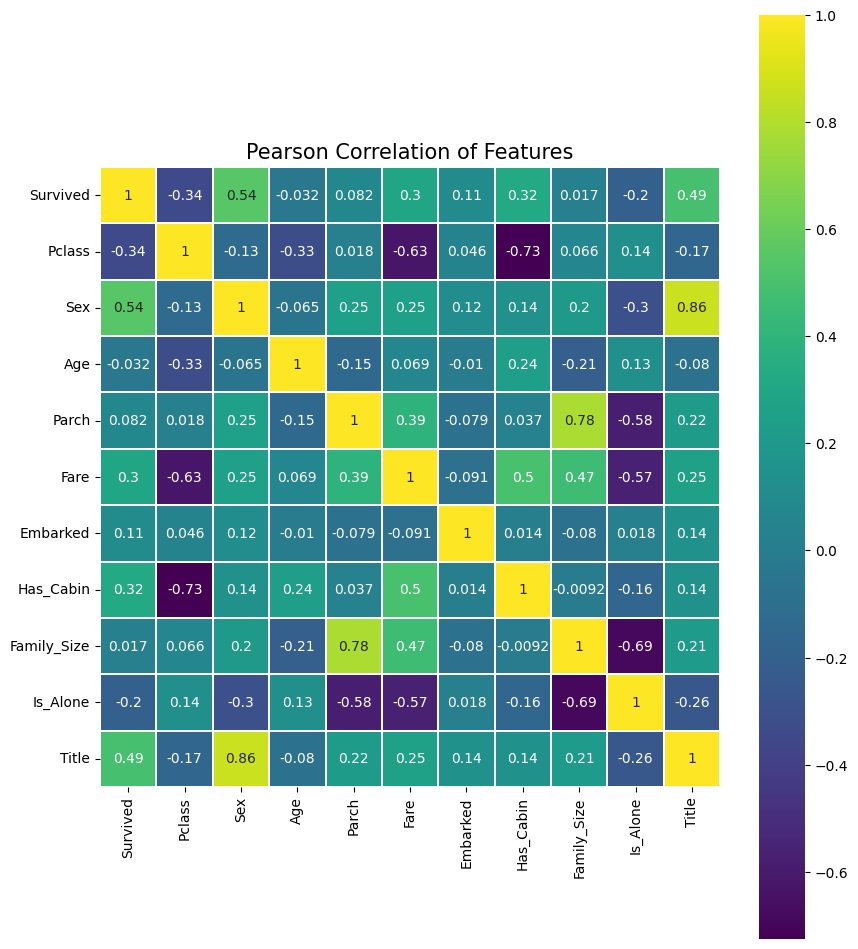

In [20]:
# Pearson correlation chart to show relationship between features - yellow shows good relationship and blue shows bad relationship
colormap=plt.cm.viridis
plt.figure(figsize=(10,12))
plt.title("Pearson Correlation of Features",y=1.00,size=15)
sns.heatmap(train.astype(float).corr(),linewidths=0.1,vmax=1.0,square=True,cmap=colormap,linecolor="white",annot=True)

###
This heatmap is very useful as an initial observation because you can easily get an idea of the predictive value of each feature. In this case, Sex and Title show the highest correlations (in absolute terms) with the class (Survived): 0.54 and 0.49 respectively. But the absolute correlation between both is also very high (0.86, the highest in our dataset), so they are probably carrying the same information and using the two as inputs for the same model wouldn't be a good idea. High chances are one of them will be used for the first node in our final decision tree, so let's first explore further these features and compare them.


In [21]:
# Based on title we will predict if passenger Survived
train[["Title","Survived"]].groupby(["Title"],as_index=False).agg(["mean","count","sum"])
# mean is the Survival rate
# count is the total observation
# sum is the people survived

Title  Survived           
             mean count  sum
0     1  0.156673   517   81
1     2  0.575000    40   23
2     3  0.793651   126  100
3     4  0.702703   185  130
4     5  0.347826    23    8

In [22]:
train[["Sex","Survived"]].groupby(["Sex"],as_index=False).agg(["mean","count","sum"])
# 1 - Female, 0 - Male
# mean is the Survival rate
# count is the total observation
# sum is the people survived

Sex  Survived           
           mean count  sum
0   0  0.188908   577  109
1   1  0.742038   314  233

In [23]:
# ??????

Title_and_Sex=original_train.copy()[["Name","Sex"]]
# Create Title feature by extracting titles from the 'Name' column
Title_and_Sex["Title"]=Title_and_Sex["Name"].apply(get_title)
# Create a new column, 'Sex_numeric', for the numerical representation of 'Sex'
Title_and_Sex["Sex_numeric"]=Title_and_Sex["Sex"].map({"female":1,"male":0}).astype(int)
# Group by the 'Title' column (containing extracted titles) and aggregate the 'Sex_numeric' column
Title_and_Sex[["Title","Sex_numeric"]].groupby(["Title"],as_index=False).agg(["mean","count","sum"])

Title Sex_numeric           
                     mean count  sum
0        Capt    0.000000     1    0
1         Col    0.000000     2    0
2    Countess    1.000000     1    1
3         Don    0.000000     1    0
4          Dr    0.142857     7    1
5    Jonkheer    0.000000     1    0
6        Lady    1.000000     1    1
7       Major    0.000000     2    0
8      Master    0.000000    40    0
9        Miss    1.000000   182  182
10       Mlle    1.000000     2    2
11        Mme    1.000000     1    1
12         Mr    0.000000   517    0
13        Mrs    1.000000   125  125
14         Ms    1.000000     1    1
15        Rev    0.000000     6    0
16        Sir    0.000000     1    0

In [24]:
# Gini Impurity? measures the disorder of the elements of the set
# Information gain tells the goodness of the node
# It will calculate the probablity of mislabelling an element assuming the element is randomly labelled according to the distribution of all the classes
# Decision tree will find the split which decreases the Gini impurity the most across the two resulting nodes

In [25]:
def get_gini_impurity(Survived_count,Total_count):
  Survived_prob=Survived_count/Total_count
  Not_Survived_prob=1-Survived_prob
  Random_observation_Survived_prob=Survived_prob
  Random_observation_Not_Survived_prob=1-Random_observation_Survived_prob
  Mislabelling_Survived_Probability=Not_Survived_prob*Random_observation_Survived_prob
  Mislabelling_Not_Survived_Probability=Survived_prob*Random_observation_Not_Survived_prob
  Gini_impurity=Mislabelling_Survived_Probability+Mislabelling_Not_Survived_Probability
  return Gini_impurity

In [26]:
Gini_impurity_Starting_node=get_gini_impurity(342,891)
Gini_impurity_Starting_node

0.47301295786144265

In [27]:
# Gini impurity decrease of node for male observations
Gini_impurity_men=get_gini_impurity(109,577)
Gini_impurity_men

0.3064437162277843

In [28]:
Gini_impurity_women=get_gini_impurity(233,314)
Gini_impurity_women

0.3828350034484158

In [29]:
# Gini_impurity decreased if node split by Sex
men_weight=577/891
women_weight=314/891
weighted_Gini_impurity_Sex=men_weight*Gini_impurity_men+women_weight*Gini_impurity_women
Sex_Gini_decrease=weighted_Gini_impurity_Sex-Gini_impurity_Starting_node
Sex_Gini_decrease

-0.13964795747285214

In [30]:
'''
342 survivors out of 891 total passengers (starting node)
→ get_gini_impurity(342, 891)

109 male survivors out of 577 males
→ get_gini_impurity(109, 577)

233 female survivors out of 314 females
→ get_gini_impurity(233, 314)

81 survivors among passengers with Title = “Mr” (517 total)
→ get_gini_impurity(81, 517)

261 survivors among all other titles (374 total)
→ get_gini_impurity(261, 374)

These values come from grouping the Titanic dataset by Sex or Title and counting how many survived.
🔍 What Survived_count means in context
On this page, Survived_count = number of people in that group whose Survived value = 1.

It is used to compute:
Survived probability
Not-survived probability
Mislabelling probabilities
Gini impurity for that node
Gini decrease when splitting by Sex or Title
In other words, Survived_count is the core input that determines how “good” a split is for a decision tree.

📌 Why it matters
A higher or lower Survived_count changes the Gini impurity:
Groups with very uneven survival rates (e.g., many survivors vs. few) → low impurity → good split
Groups with mixed survival → high impurity → weaker split
This is why the notebook compares splits by Sex and Title.
'''

'\n342 survivors out of 891 total passengers (starting node)\n→ get_gini_impurity(342, 891)\n\n109 male survivors out of 577 males\n→ get_gini_impurity(109, 577)\n\n233 female survivors out of 314 females\n→ get_gini_impurity(233, 314)\n\n81 survivors among passengers with Title = “Mr” (517 total)\n→ get_gini_impurity(81, 517)\n\n261 survivors among all other titles (374 total)\n→ get_gini_impurity(261, 374)\n\nThese values come from grouping the Titanic dataset by Sex or Title and counting how many survived.\n🔍 What Survived_count means in context\nOn this page, Survived_count = number of people in that group whose Survived value = 1.\n\nIt is used to compute:\nSurvived probability\nNot-survived probability\nMislabelling probabilities\nGini impurity for that node\nGini decrease when splitting by Sex or Title\nIn other words, Survived_count is the core input that determines how “good” a split is for a decision tree.\n\n📌 Why it matters\nA higher or lower Survived_count changes the Gini

In [31]:
# If split by Title
Gini_impurity_Title_Mr=get_gini_impurity(81,517)
Gini_impurity_Title_Mr

0.26425329886377663

In [32]:
# Where not 'Mr', but rest of the other Titles
Gini_impurity_Title_others=get_gini_impurity(261,374)
Gini_impurity_Title_others

0.42170207898424317

In [33]:
# Gini impurity decrease if node split with observation with Title ==1 (Mr)
Mr_weight=517/891
others_weight=374/891
Weighted_Gini_impurity_Title_split=(Gini_impurity_Title_Mr*Mr_weight)+(Gini_impurity_Title_others*others_weight)
Title_Gini_decrease=Weighted_Gini_impurity_Title_split-Gini_impurity_Starting_node  # when starting the tree, the Starting node is identified
Title_Gini_decrease


-0.14267004758907514

In [34]:
# Start with cross validation - dividing data into equal 10parts
# ??? learn gini_impurity, cross_validation and information_gain
# Overfitting hides meaningful relationship

In [35]:
# Cross validation is a robust method - splits training data into equal parts. Each split uses different data for training / testing. Using decision-tree algorithm

In [36]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from IPython.display import Image as PImage
from subprocess import check_call
from PIL import Image, ImageDraw, ImageFont
from sklearn import tree
from sklearn.metrics import accuracy_score


In [37]:
cv=KFold(n_splits=10)
accuracies=list()
max_attributes=len(list(train))
depth_range=range(1,max_attributes+1)

# testing max depth from 1 to max attributes
for depth in depth_range:
  fold_accuracy=[]
  tree_model=tree.DecisionTreeClassifier(max_depth=depth)
  for train_fold,valid_fold in cv.split(train):
    ftrain=train.loc[train_fold]
    fvalid=train.loc[valid_fold]
    model=tree_model.fit(X=ftrain.drop(["Survived"],axis=1),y=ftrain["Survived"])
    valid_acc=model.score(X=fvalid.drop(["Survived"],axis=1),y=fvalid["Survived"])
    fold_accuracy.append(valid_acc)
  avg=sum(fold_accuracy)/len(fold_accuracy)
  accuracies.append(avg)
df=pd.DataFrame({"Max Depth":depth_range,"Average Accuracy":accuracies})
df=df[["Max Depth","Average Accuracy"]]
print(df.to_string(index=False))

 Max Depth  Average Accuracy
         1          0.782285
         2          0.799189
         3          0.828277
         4          0.818165
         5          0.813708
         6          0.806954
         7          0.808102
         8          0.812609
         9          0.815955
        10          0.818202
        11          0.808090


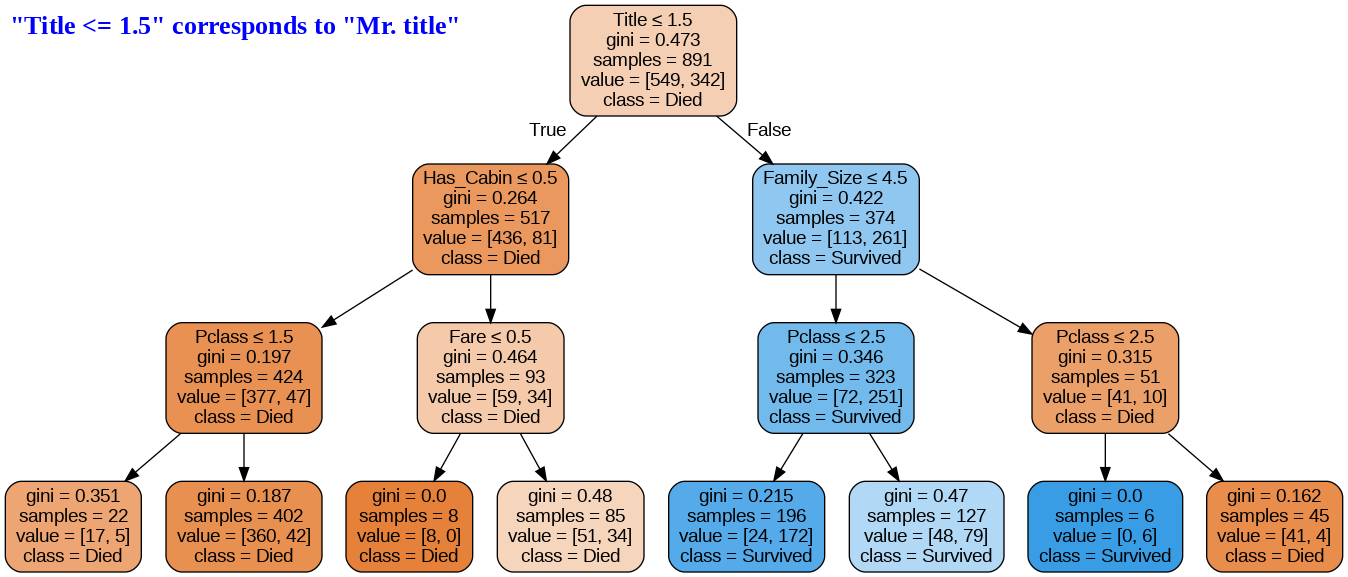

In [38]:
# Final tree
ytrain=train["Survived"]
xtrain=train.drop(["Survived"],axis=1).values
xtest=test.values
# Create decision tree with max depth = 3
decision_tree=tree.DecisionTreeClassifier(max_depth=3)
decision_tree.fit(xtrain,ytrain)
# predicting results for test data set
ypred=decision_tree.predict(xtest)
submission=pd.DataFrame({"PassengerId":"PassengerId","Survived":ypred})
submission.to_csv("submission.csv",index=False)
# export our trained model as a .dot file
with open("tree1.dot","w") as f:
  f=tree.export_graphviz(decision_tree,out_file=f,
                         max_depth=3,impurity=True,feature_names=list(train.drop(["Survived"],axis=1)),
                         class_names=["Died","Survived"],
                         filled=True,rounded=True,
                         special_characters=True)
check_call(["dot","-Tpng","tree1.dot","-o","tree1.png"])
# annotating chart with PIL
img=Image.open("tree1.png")
draw=ImageDraw.Draw(img)
font=ImageFont.truetype("/usr/share/fonts/truetype/liberation/LiberationSerif-Bold.ttf",26)
draw.text((10,10),'"Title <= 1.5" corresponds to "Mr. title"',(0,0,255),font=font)
img.save("Sample_out.png")
PImage("Sample_out.png")


In [39]:
# Q - adv of decision tree
# Q - where is it applied
# Q - benefits of decision tree
# ??? Imp - prompt engineering from Microsoft

In [40]:
# accuracy of the decision tree
acc_decision_tree=round(decision_tree.score(xtrain,ytrain)*100,2)
acc_decision_tree

82.38